# Common

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any, Callable, List
from scipy.optimize import curve_fit
import sys

np.set_printoptions(linewidth=200)

In [ ]:
# --- Класс для параметров стиля ---
@dataclass
class PlotParams:
    """Контейнер для параметров стиля отрисовки."""
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

# --- Класс-обертка для Matplotlib ---
class Plotter:
    """Класс для инкапсуляции всей логики построения графиков."""
    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        """Инициализирует фигуру и оси, задает основные подписи."""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает точки."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def add_fit_line(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает сплошную линию (обычно для аппроксимации)."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
        )

    def add_errorbar_points(self, x: np.ndarray, y: np.ndarray,
                            xerr: Optional[np.ndarray], yerr: Optional[np.ndarray],
                            params: PlotParams):
        """Отрисовывает экспериментальные точки с погрешностями."""
        self.ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt=params.marker,
            color=params.color,
            markersize=params.markersize,
            elinewidth=params.linewidth,
            capsize=params.capsize,
            capthick=params.linewidth,
            markevery=params.markevery,
            label=params.label
        )

    def finalize_and_show(self, save_path: Optional[str] = None):
        """Настраивает финальное оформление, сохраняет и/или показывает график."""
        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [3]:
m = 9.1 * 10 ** (-31)
h = 6.6 * 10 ** (-34)
c = 3 * 10 ** 8
e = 1.6 * 10 ** (-19)
h_bar = h / (2 * np.pi)

In [4]:
U_0 = 2.5 * e          # eV -> J
a_ref = 6 * 10**(-10)  # a0 -> m
alpha_ref_1_inverted = 0.5  # E < U_0
alpha_ref_2_inverted = 1.5  # E > U_0

def T(a, alpha):
    
    if alpha > 1:
        kappa = np.sqrt((2*m*(U_0 - U_0/alpha)) / (h_bar**2))
        return 1 / (1 - alpha**2 / (4*(1-alpha)) * np.sinh(kappa*a)**2)
    elif alpha < 1:
        k2 = np.sqrt((2*m*(U_0/alpha-U_0)) / (h_bar**2))
        return 1 / (1 + alpha**2 / (4*(1-alpha)) * np.sin(k2*a)**2)
    else:
        raise ValueError(rf'$E = U_0$ is prohibited)')
                

In [ ]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "T(a)_1":     PlotParams(linestyle="-", color="black", linewidth=1, label=r'T(a), $\frac{1}{\alpha}$ = 0.5'),
    "T(a)_2":     PlotParams(linestyle="-", color="black", linewidth=1, label=r'T(a), $\frac{1}{\alpha}$ = 1.5'),
    "T(1/alpha)": PlotParams(linestyle="-", color="black", linewidth=1, label=r'T($\frac{1}{\alpha}$), a = 16 Angstrom'),
}

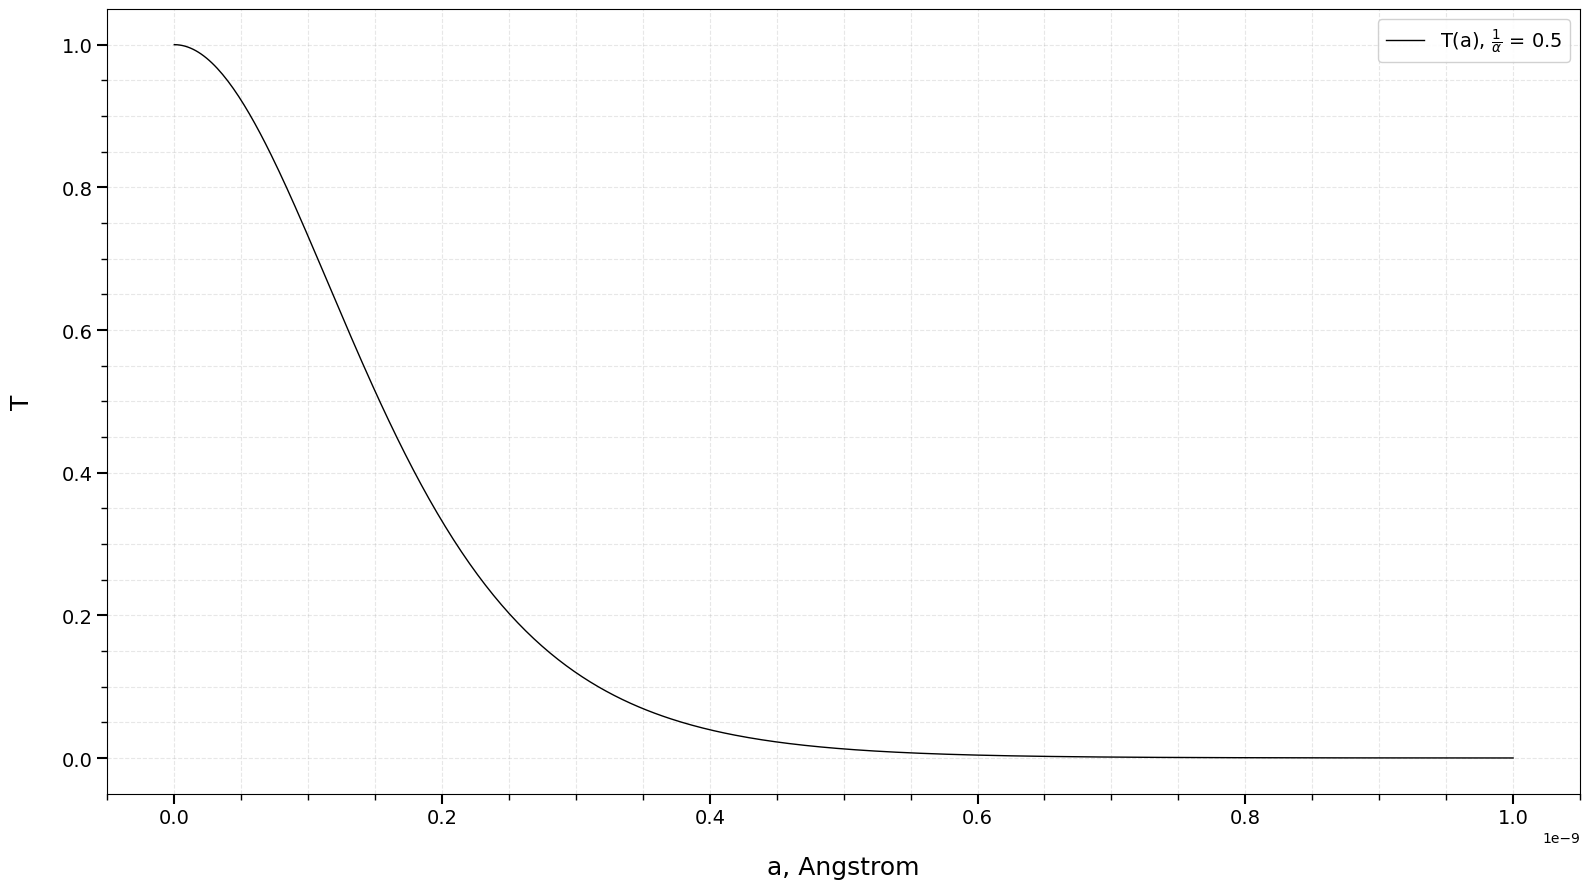

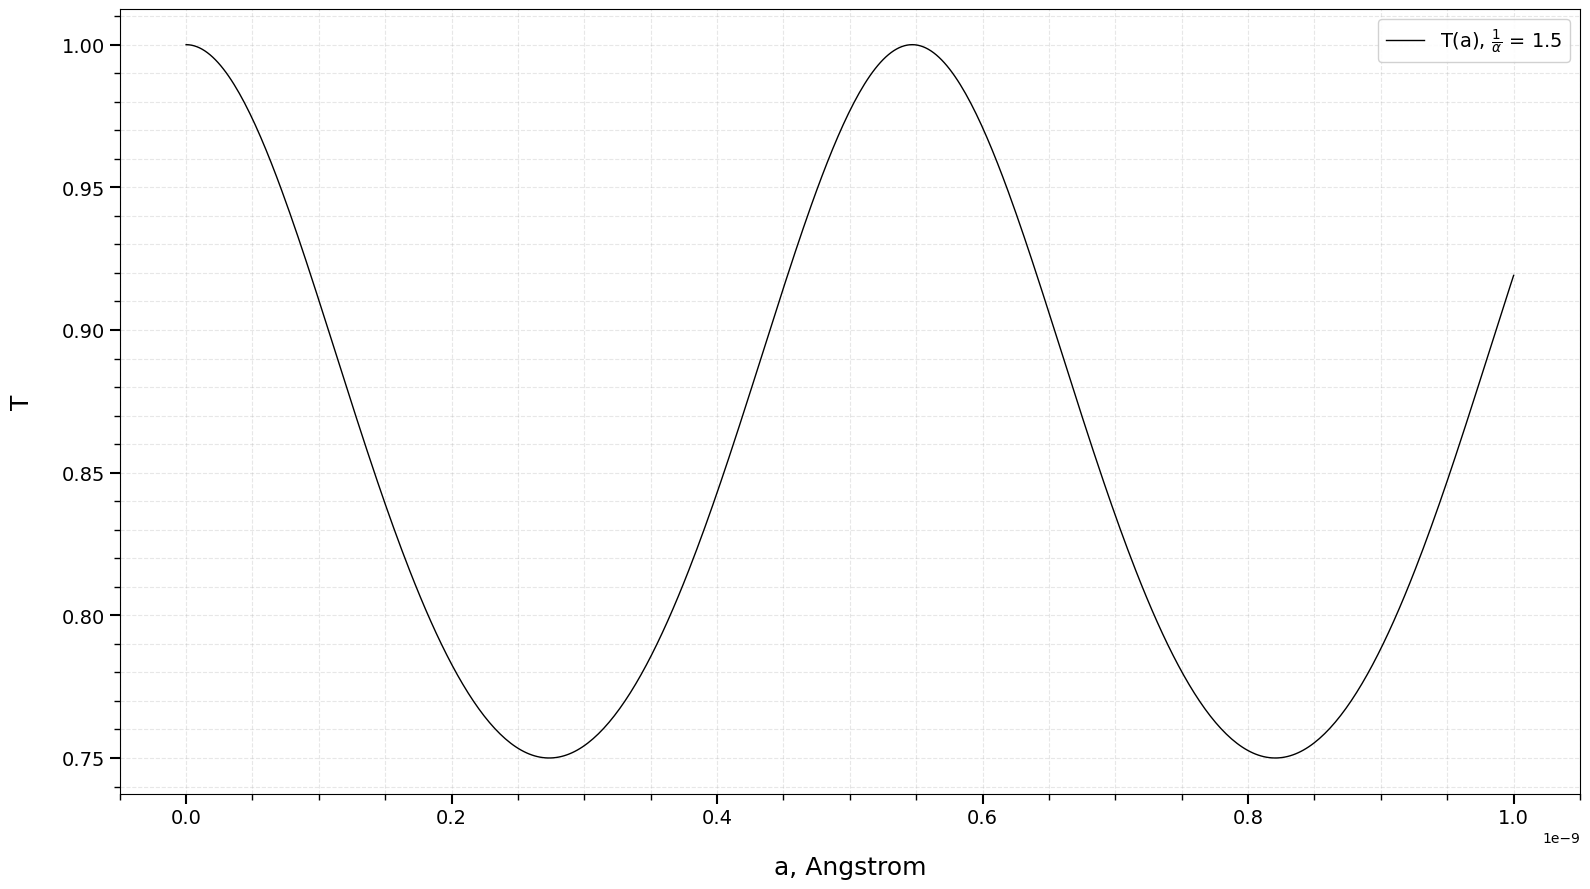

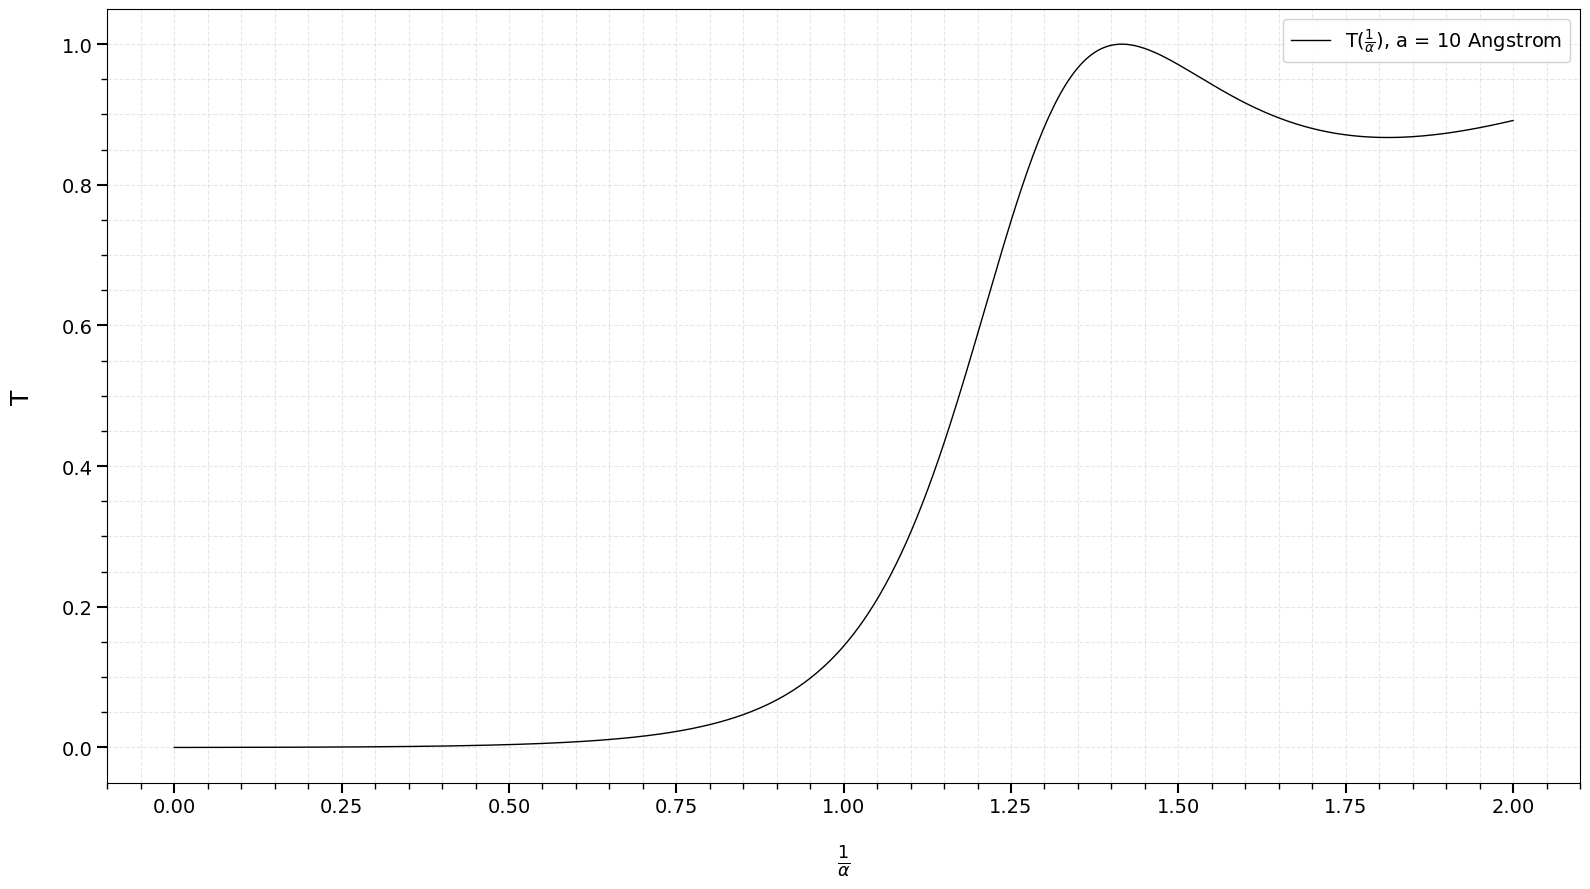

In [7]:
# 1. Кривая T(a)
a_arr = np.linspace(0, 10 * 10**(-10), 500) 

# Добавляем кривую 1 (T(a)) для случая E < U_0

plotter_a = Plotter(
    title=r'',
    xlabel=r'a, Angstrom',
    ylabel=f'T'
)

T_a_1 = []
for a in a_arr:
    T_a_1.append(T(a, 1 / alpha_ref_1_inverted))
plotter_a.add_plot(a_arr, T_a_1, plot_args_dict["T(a)_1"])
plotter_a.finalize_and_show()

# Добавляем кривую 2 (T(a)) для случая E > U_0

plotter_a = Plotter(
    title=r'',
    xlabel=r'a, Angstrom',
    ylabel=f'T'
)

T_a_2 = []
for a in a_arr:
    T_a_2.append(T(a, 1 / alpha_ref_2_inverted))
plotter_a.add_plot(a_arr, T_a_2, plot_args_dict["T(a)_2"])
plotter_a.finalize_and_show()

# 2. Кривая T(1/alpha)

plotter_alpha = Plotter(
    title=r'',
    xlabel=r'$\frac{1}{\alpha}$',
    ylabel=f'T'
)

alpha_inverted_arr = np.linspace(0.0000000001, 2, 500) 

T_alpha = []
for alpha_inverted in alpha_inverted_arr:
    T_alpha.append(T(a_ref, 1 / alpha_inverted))
plotter_alpha.add_plot(alpha_inverted_arr, T_alpha, plot_args_dict["T(1/alpha)"])
plotter_alpha.finalize_and_show()
